## Conhecendo os dados

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
url = 'https://raw.githubusercontent.com/alura-cursos/selecao-de-features/refs/heads/main/dados/hotel.csv'
df = pd.read_csv(url)

In [121]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status
0,2,0,2,2,0,82,2018,10,30,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,0,1,0,109,2017,7,16,0,...,0,0,0,0,0,0,0,0,1,1
2,2,0,0,1,0,105,2018,4,6,0,...,0,0,0,0,0,0,0,1,0,1
3,1,0,0,3,0,13,2018,4,19,0,...,0,0,0,0,1,0,0,0,0,0
4,2,0,0,2,0,81,2018,8,5,0,...,1,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34141,2,0,1,2,0,305,2018,11,4,0,...,0,0,0,0,0,0,0,1,0,1
34142,2,0,0,3,0,67,2018,9,28,0,...,0,0,0,0,0,0,0,0,1,1
34143,1,0,0,2,0,193,2018,6,20,0,...,0,0,0,0,0,0,0,0,1,1
34144,2,0,2,1,0,85,2017,7,5,0,...,0,0,0,0,0,0,0,0,1,1


In [122]:
colunas_traduzidas = {
    'no_of_adults': 'numero_de_adultos',
    'no_of_children': 'numero_de_criancas',
    'no_of_weekend_nights': 'numero_de_noites_fim_de_semana',
    'no_of_week_nights': 'numero_de_noites_semana',
    'required_car_parking_space': 'espaco_estacionamento_necessario',
    'lead_time': 'tempo de espera',
    'arrival_year': 'ano_chegada',
    'arrival_month': 'mes_chegada',
    'arrival_date': 'dia_chegada',
    'repeated_guest': 'hospede_repetido',
    'no_of_previous_cancellations': 'numero_cancelamentos_anteriores',
    'no_of_previous_bookings_not_canceled': 'numero_reservas_anteriores_nao_canceladas',
    'avg_price_per_room': 'preco_medio_por_quarto',
    'no_of_special_requests': 'numero_pedidos_especiais',
    'type_of_meal_plan_Meal Plan 1': 'tipo_plano_refeicao_Plano_1',
    'type_of_meal_plan_Meal Plan 2': 'tipo_plano_refeicao_Plano_2',
    'type_of_meal_plan_Meal Plan 3': 'tipo_plano_refeicao_Plano_3',
    'type_of_meal_plan_Not Selected': 'tipo_plano_refeicao_Nao_Selecionado',
    'room_type_reserved_Room_Type 1': 'tipo_quarto_reservado_Tipo_1',
    'room_type_reserved_Room_Type 2': 'tipo_quarto_reservado_Tipo_2',
    'room_type_reserved_Room_Type 3': 'tipo_quarto_reservado_Tipo_3',
    'room_type_reserved_Room_Type 4': 'tipo_quarto_reservado_Tipo_4',
    'room_type_reserved_Room_Type 5': 'tipo_quarto_reservado_Tipo_5',
    'room_type_reserved_Room_Type 6': 'tipo_quarto_reservado_Tipo_6',
    'room_type_reserved_Room_Type 7': 'tipo_quarto_reservado_Tipo_7',
    'market_segment_type_Aviation': 'segmento_mercado_Aviacao',
    'market_segment_type_Complementary': 'segmento_mercado_Complementar',
    'market_segment_type_Corporate': 'segmento_mercado_Corporativo',
    'market_segment_type_Offline': 'segmento_mercado_Offline',
    'market_segment_type_Online': 'segmento_mercado_Online',
    'booking_status': 'status_reserva'
}
df = df.rename(columns=colunas_traduzidas)
display(df.head())

,numero_de_adultos,numero_de_criancas,numero_de_noites_fim_de_semana,numero_de_noites_semana,espaco_estacionamento_necessario,tempo de espera,ano_chegada,mes_chegada,dia_chegada,hospede_repetido,...,tipo_quarto_reservado_Tipo_4,tipo_quarto_reservado_Tipo_5,tipo_quarto_reservado_Tipo_6,tipo_quarto_reservado_Tipo_7,segmento_mercado_Aviacao,segmento_mercado_Complementar,segmento_mercado_Corporativo,segmento_mercado_Offline,segmento_mercado_Online,status_reserva
0,2,0,2,2,0,82,2018,10,30,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,0,1,0,109,2017,7,16,0,...,0,0,0,0,0,0,0,0,1,1
2,2,0,0,1,0,105,2018,4,6,0,...,0,0,0,0,0,0,0,1,0,1
3,1,0,0,3,0,13,2018,4,19,0,...,0,0,0,0,1,0,0,0,0,0
4,2,0,0,2,0,81,2018,8,5,0,...,1,0,0,0,0,0,0,0,1,1


In [123]:
explicacao_colunas = {
    'numero_de_adultos': 'Número de adultos na reserva.',
    'numero_de_criancas': 'Número de crianças na reserva.',
    'numero_de_noites_fim_de_semana': 'Número de noites de fim de semana (sábado ou domingo) reservadas.',
    'numero_de_noites_semana': 'Número de noites de semana (segunda a sexta) reservadas.',
    'espaco_estacionamento_necessario': 'Indica se um espaço de estacionamento foi solicitado (1 para sim, 0 para não).',
    'tempo_antecedencia': 'Número de dias entre a data da reserva e a data de chegada.',
    'ano_chegada': 'Ano da chegada.',
    'mes_chegada': 'Mês da chegada.',
    'dia_chegada': 'Dia da chegada.',
    'hospede_repetido': 'Indica se o hóspede é um hóspede repetido (1 para sim, 0 para não).',
    'numero_cancelamentos_anteriores': 'Número de reservas anteriores que foram canceladas pelo cliente.',
    'numero_reservas_anteriores_nao_canceladas': 'Número de reservas anteriores que não foram canceladas pelo cliente.',
    'preco_medio_por_quarto': 'Preço médio por quarto por dia.',
    'numero_pedidos_especiais': 'Número de pedidos especiais feitos pelo cliente.',
    'tipo_plano_refeicao_Plano_1': 'Indica se o plano de refeição selecionado foi o Plano 1 (1 para sim, 0 para não).',
    'tipo_plano_refeicao_Plano_2': 'Indica se o plano de refeição selecionado foi o Plano 2 (1 para sim, 0 para não).',
    'tipo_plano_refeicao_Plano_3': 'Indica se o plano de refeição selecionado foi o Plano 3 (1 para sim, 0 para não).',
    'tipo_plano_refeicao_Nao_Selecionado': 'Indica se nenhum plano de refeição foi selecionado (1 para sim, 0 para não).',
    'tipo_quarto_reservado_Tipo_1': 'Indica se o tipo de quarto reservado foi o Tipo 1 (1 para sim, 0 para não).',
    'tipo_quarto_reservado_Tipo_2': 'Indica se o tipo de quarto reservado foi o Tipo 2 (1 para sim, 0 para não).',
    'tipo_quarto_reservado_Tipo_3': 'Indica se o tipo de quarto reservado foi o Tipo 3 (1 para sim, 0 para não).',
    'tipo_quarto_reservado_Tipo_4': 'Indica se o tipo de quarto reservado foi o Tipo 4 (1 para sim, 0 para não).',
    'tipo_quarto_reservado_Tipo_5': 'Indica se o tipo de quarto reservado foi o Tipo 5 (1 para sim, 0 para não).',
    'tipo_quarto_reservado_Tipo_6': 'Indica se o tipo de quarto reservado foi o Tipo 6 (1 para sim, 0 para não).',
    'tipo_quarto_reservado_Tipo_7': 'Indica se o tipo de quarto reservado foi o Tipo 7 (1 para sim, 0 para não).',
    'segmento_mercado_Aviacao': 'Indica se o segmento de mercado da reserva foi Aviação (1 para sim, 0 para não).',
    'segmento_mercado_Complementar': 'Indica se o segmento de mercado da reserva foi Complementar (1 para sim, 0 para não).',
    'segmento_mercado_Corporativo': 'Indica se o segmento de mercado da reserva foi Corporativo (1 para sim, 0 para não).',
    'segmento_mercado_Offline': 'Indica se o segmento de mercado da reserva foi Offline (1 para sim, 0 para não).',
    'segmento_mercado_Online': 'Indica se o segmento de mercado da reserva foi Online (1 para sim, 0 para não).',
    'status_reserva': 'Status da reserva (0 para cancelada, 1 para não cancelada).'
}

for coluna, explicacao in explicacao_colunas.items():
    print(f"{coluna}: {explicacao}")

numero_de_adultos: Número de adultos na reserva.
numero_de_criancas: Número de crianças na reserva.
numero_de_noites_fim_de_semana: Número de noites de fim de semana (sábado ou domingo) reservadas.
numero_de_noites_semana: Número de noites de semana (segunda a sexta) reservadas.
espaco_estacionamento_necessario: Indica se um espaço de estacionamento foi solicitado (1 para sim, 0 para não).
tempo_antecedencia: Número de dias entre a data da reserva e a data de chegada.
ano_chegada: Ano da chegada.
mes_chegada: Mês da chegada.
dia_chegada: Dia da chegada.
hospede_repetido: Indica se o hóspede é um hóspede repetido (1 para sim, 0 para não).
numero_cancelamentos_anteriores: Número de reservas anteriores que foram canceladas pelo cliente.
numero_reservas_anteriores_nao_canceladas: Número de reservas anteriores que não foram canceladas pelo cliente.
preco_medio_por_quarto: Preço médio por quarto por dia.
numero_pedidos_especiais: Número de pedidos especiais feitos pelo cliente.
tipo_plano_re

In [124]:
# verificando se há valores nulos
df.isnull().sum().sum()

np.int64(0)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34146 entries, 0 to 34145
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   numero_de_adultos                          34146 non-null  int64  
 1   numero_de_criancas                         34146 non-null  int64  
 2   numero_de_noites_fim_de_semana             34146 non-null  int64  
 3   numero_de_noites_semana                    34146 non-null  int64  
 4   espaco_estacionamento_necessario           34146 non-null  int64  
 5   tempo de espera                            34146 non-null  int64  
 6   ano_chegada                                34146 non-null  int64  
 7   mes_chegada                                34146 non-null  int64  
 8   dia_chegada                                34146 non-null  int64  
 9   hospede_repetido                           34146 non-null  int64  
 10  numero_cancelamentos_a

### Treinando um modelo

In [126]:
X = df.drop(columns = 'status_reserva')

In [127]:
y = df['status_reserva']

In [128]:
y.value_counts(normalize=True)

,proportion
status_reserva,
0,0.5
1,0.5


In [129]:
from sklearn.model_selection import train_test_split

In [130]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.3, stratify=y, random_state=50)

In [131]:
from sklearn.ensemble import RandomForestClassifier

In [132]:
modelo = RandomForestClassifier(random_state=2)

In [79]:
modelo.fit(X_treino, y_treino)

RandomForestClassifier(random_state=2)

In [80]:
print(f'Dados de treino: {modelo.score(X_treino, y_treino):.2f}')
print(f'Dados de teste: {modelo.score(X_teste, y_teste):.2f}')

Dados de treino: 1.00
Dados de teste: 0.92


In [81]:
# analisando se os dados estão balanceados
df['status_reserva'].value_counts(normalize=True)

,proportion
status_reserva,
0,0.5
1,0.5


## Análise de dados

### Entendendo as features

<Axes: xlabel='status_reserva', ylabel='mes_chegada'>

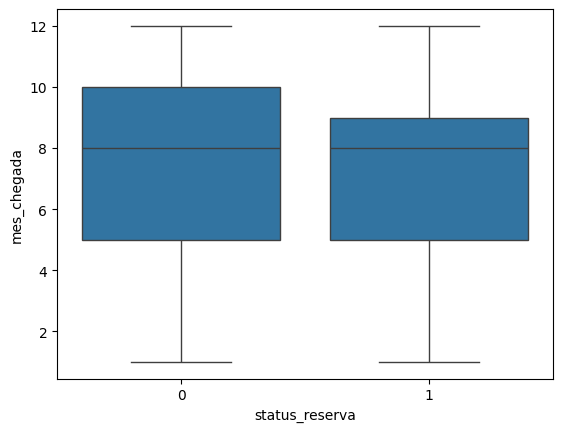

In [82]:
sns.boxplot(X_treino, x=y_treino, y='mes_chegada')

<Axes: xlabel='status_reserva', ylabel='mes_chegada'>

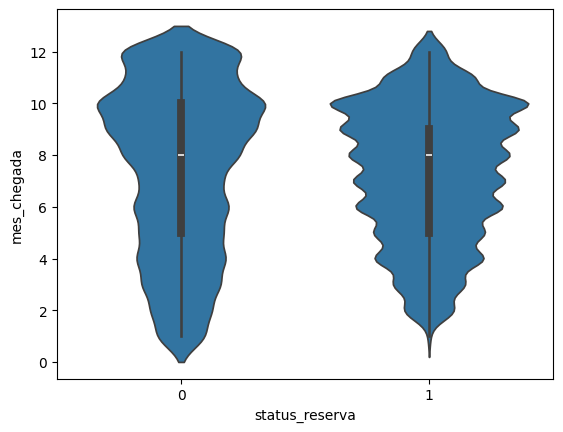

In [83]:
sns.violinplot(X_treino, x=y_treino, y='mes_chegada')

<Axes: xlabel='status_reserva', ylabel='tempo de espera'>

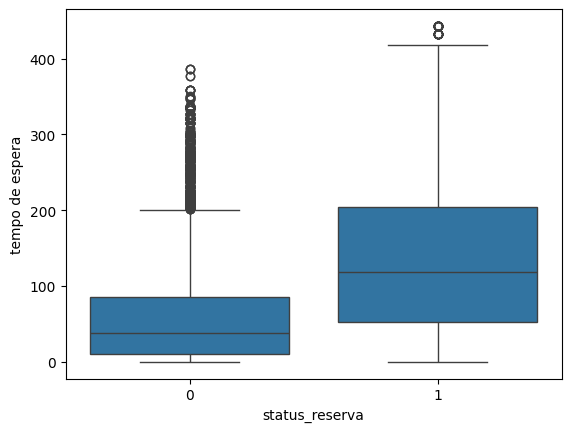

In [84]:
sns.boxplot(X_treino, x=y_treino, y='tempo de espera')

### Correlação entre features

In [85]:
correlacao = pd.concat([X_treino, y_treino], axis=1).corr()

<Axes: >

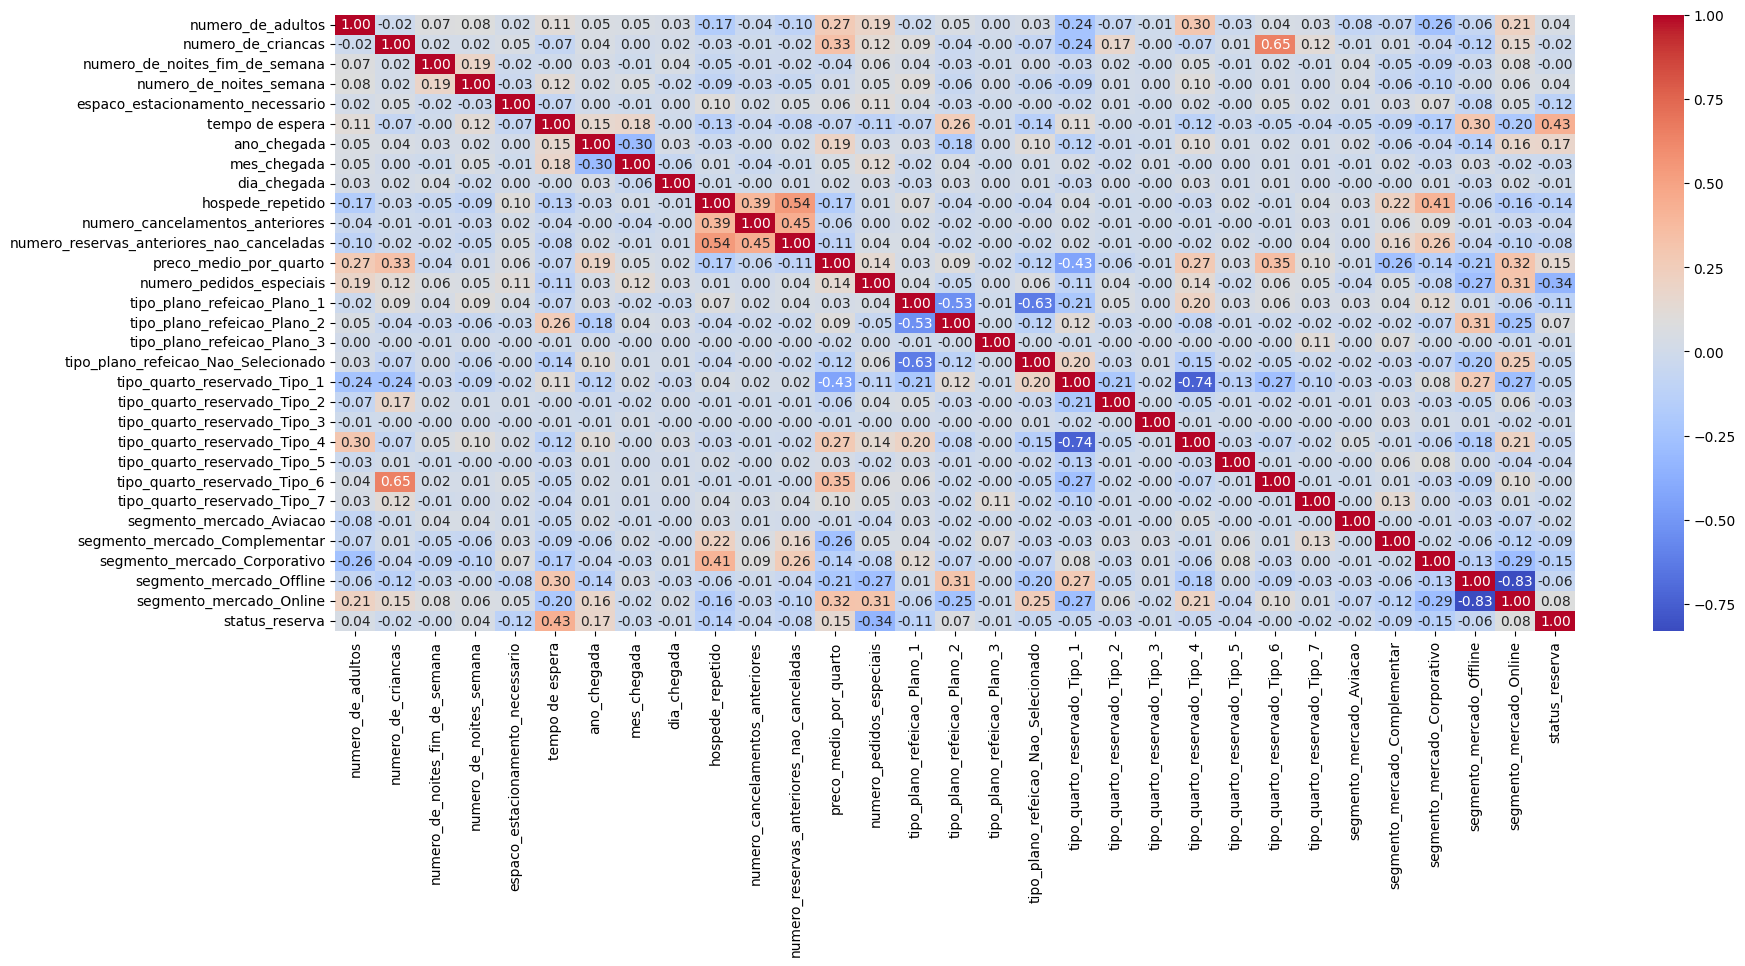

In [86]:
plt.figure(figsize=(20,8))

sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')

### Feature importance

In [87]:
modelo = RandomForestClassifier(random_state=2)
modelo.fit(X_treino, y_treino)

importancia = pd.DataFrame({'colunas': X_treino.columns, 'importancia': modelo.feature_importances_})

In [88]:
top10 = importancia.sort_values(by='importancia', ascending=False).head(10)

/tmp/ipython-input-2007583043.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75)


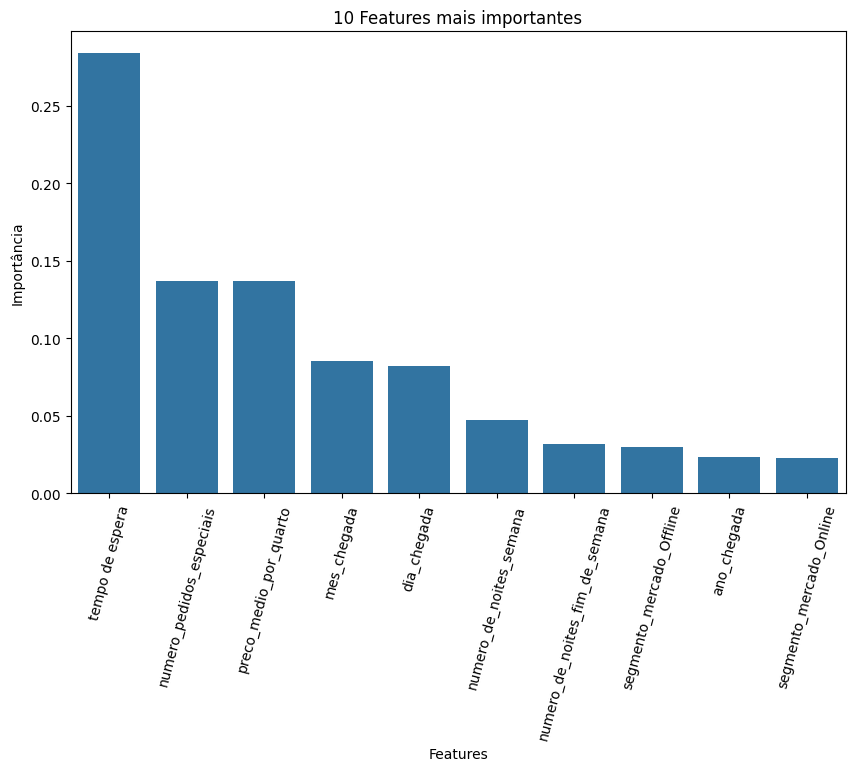

In [89]:
plt.figure(figsize=(10,6))

ax = sns.barplot(x='colunas', y='importancia', data=top10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=75)

plt.title('10 Features mais importantes')
plt.xlabel('Features')
plt.ylabel('Importância')

plt.show()

## Automatizando a seleção



### SelectFromModel

In [90]:
from sklearn.feature_selection import SelectFromModel

In [91]:
modelo_fselecionadas = SelectFromModel(modelo, max_features=10, prefit=True)

In [92]:
X_treino_selecionado = modelo_fselecionadas.transform(X_treino)
X_teste_selecionado = modelo_fselecionadas.transform(X_teste)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [93]:
modelo = RandomForestClassifier(random_state=2)

modelo.fit(X_treino_selecionado, y_treino)
print(f'Dados de treino: {modelo.score(X_treino_selecionado, y_treino):.2f}')
print(f'Dados de teste: {modelo.score(X_teste_selecionado, y_teste):.2f}')

Dados de treino: 0.99
Dados de teste: 0.90


### Validação cruzada e otimização

In [94]:
from sklearn.model_selection import GridSearchCV

In [95]:
modelo = RandomForestClassifier(random_state=2)

In [96]:
parametros_busca = {
    'n_estimators':[100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [97]:
grid_search = GridSearchCV(estimator=modelo, param_grid=parametros_busca,
                           scoring='accuracy',
                           cv=5,
                           n_jobs=-1)

In [98]:
grid_search.fit(X_treino, y_treino)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=2), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [99]:
grid_search.cv_results_

{'mean_fit_time': array([ 4.57645507,  8.38804264, 11.76884532,  3.73598661,  7.27607088,
        11.25309515,  3.37193537,  7.00216799, 10.42595062,  3.33975759,
         6.89916558, 10.43772087,  2.31148562,  4.67781219,  6.62262168,
         2.44197559,  4.44777265,  6.95447068,  2.0604557 ,  4.55916471,
         6.57561736,  2.57434983,  4.32215443,  6.73924761,  3.72328701,
         6.96848836, 10.66004634,  3.62389588,  6.75138049, 10.41059484,
         3.486514  ,  6.45328393,  9.92044811,  2.96386037,  6.6493681 ,
         9.49773421]),
 'std_fit_time': array([0.91629761, 0.97679316, 0.45712891, 0.36268492, 0.58324643,
        0.30207667, 0.45154906, 0.58414771, 0.61258385, 0.41351586,
        0.57712813, 0.68477826, 0.4476954 , 0.68679001, 0.52500694,
        0.5047521 , 0.52897006, 0.68767791, 0.00937249, 0.26050732,
        0.68995953, 0.67408866, 0.51123328, 0.5244613 , 0.67285747,
        0.61828063, 0.51420953, 0.54922587, 0.66491737, 0.48509043,
        0.63160338, 0.692

In [100]:
modelo_fselecionadas = SelectFromModel(grid_search.best_estimator_, max_features=10, prefit=True)

In [101]:
X_treino_selecionado = modelo_fselecionadas.transform(X_treino)
X_teste_selecionado = modelo_fselecionadas.transform(X_teste)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [102]:
modelo = grid_search.best_estimator_

In [103]:
modelo.fit(X_treino_selecionado, y_treino)
print(f'Dados de treino: {modelo.score(X_treino_selecionado, y_treino):.2f}')
print(f'Dados de teste: {modelo.score(X_teste_selecionado, y_teste):.2f}')

Dados de treino: 0.99
Dados de teste: 0.90


### Matriz de confusão

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [105]:
y_pred = modelo.predict(X_teste_selecionado)

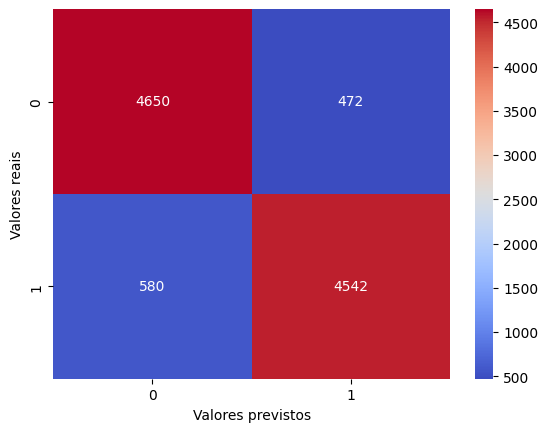

In [106]:
matriz_confusao = confusion_matrix(y_teste, y_pred)

sns.heatmap(matriz_confusao, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel('Valores previstos')
plt.ylabel('Valores reais')
plt.show()

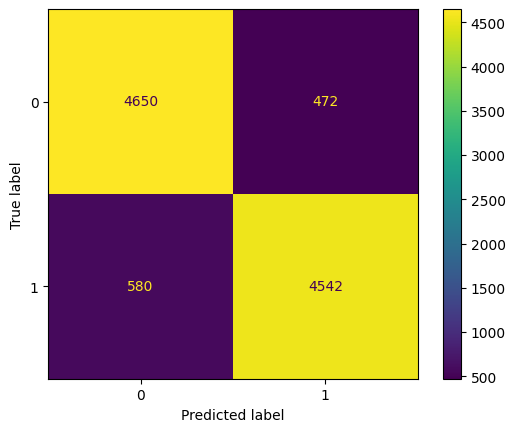

In [107]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=modelo.classes_)
visualizacao.plot()

### Curva ROC

In [108]:
from sklearn.metrics import roc_curve, auc

In [109]:
fpr, tpr, treshoulds = roc_curve(y_teste, y_pred)

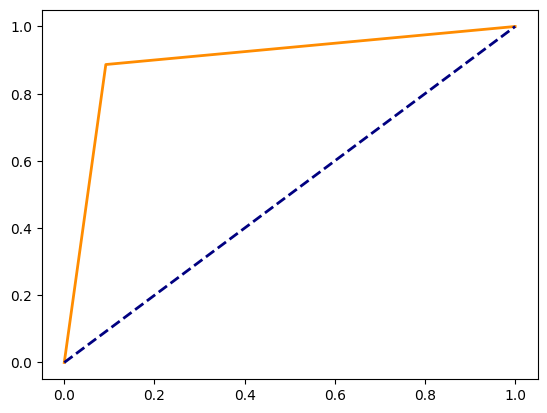

In [110]:
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

In [111]:
roc_auc = auc(fpr, tpr)
roc_auc

np.float64(0.8973057399453339)

## Avaliação de resultados

### Seleção com RFE

In [112]:
from sklearn.feature_selection import RFE

In [113]:
grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [114]:
parametros = {
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 300,
    'random_state': 2
    }

In [115]:
modelo = RandomForestClassifier(**parametros)

In [116]:
selecionador = RFE(modelo, n_features_to_select=10, step=1)

In [117]:
selecionador.fit(X_treino, y_treino)

RFE(estimator=RandomForestClassifier(n_estimators=300, random_state=2),
    n_features_to_select=10)

In [118]:
X_treino_selecionado = selecionador.transform(X_treino)
X_teste_selecionado = selecionador.transform(X_teste)

In [136]:
modelo.fit(X_treino_selecionado,y_treino)
print(f'Dados de treino: {modelo.score(X_treino_selecionado, y_treino):.2f}')
print(f'Dados de teste: {modelo.score(X_teste_selecionado, y_teste):.2}')

Dados de treino: 1.00
Dados de teste: 0.91


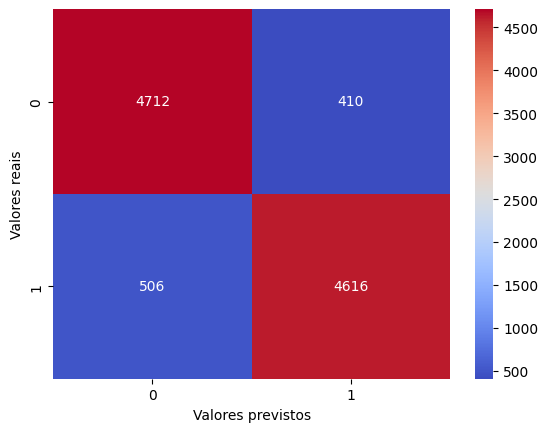

In [138]:
y_pred = modelo.predict(X_teste_selecionado)

matriz_confusao = confusion_matrix(y_teste, y_pred)

sns.heatmap(matriz_confusao, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel('Valores previstos')
plt.ylabel('Valores reais')
plt.show()

### Seleção com RFECV

In [139]:
modelo = RandomForestClassifier(**parametros)

In [142]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

In [144]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=500)

rfecv = RFECV(estimator=modelo,
              cv=cv,
              scoring='roc_auc',
              min_features_to_select=1,
              importance_getter='auto'
              )

In [145]:
rfecv = rfecv.fit(X_treino, y_treino)

In [146]:
print(f'Número ideal de features é: {rfecv.n_features_}')

Número ideal de features é: 25


In [147]:
print(f'O ranking das features: {rfecv.ranking_}')

O ranking das features: [1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 6 1 1 1 5 1 1 1 4 2 1 1 1 1]


In [148]:
print(f'Score: {rfecv.cv_results_}')

Score: {'mean_test_score': array([0.76154345, 0.87839775, 0.90458683, 0.94491056, 0.95526299,
       0.95713147, 0.96172095, 0.9619459 , 0.96508946, 0.96545119,
       0.96600555, 0.96636283, 0.96654828, 0.96653068, 0.96700983,
       0.96842023, 0.96922436, 0.96933057, 0.96897245, 0.96914412,
       0.96911669, 0.96916082, 0.96924454, 0.96912505, 0.96992768,
       0.96991859, 0.96983684, 0.96988479, 0.96954651, 0.96953734]), 'std_test_score': array([0.02230485, 0.00513526, 0.00256538, 0.00215576, 0.00235998,
       0.00214142, 0.00143015, 0.00134581, 0.0012676 , 0.00140743,
       0.001545  , 0.00160935, 0.00118657, 0.00139523, 0.00150719,
       0.00162719, 0.00170077, 0.00154041, 0.00171934, 0.00164235,
       0.00144254, 0.00143644, 0.00120112, 0.00121457, 0.00127118,
       0.00121897, 0.00149984, 0.00099933, 0.00123228, 0.00116114]), 'split0_test_score': array([0.77913523, 0.88305492, 0.90862325, 0.94651964, 0.95776255,
       0.95994017, 0.96338291, 0.96326103, 0.96628728, 0.96

In [159]:
features_rank = pd.DataFrame({
    'Feature': X_treino.columns, # Use o nome das suas colunas aqui
    'Ranking': rfecv.ranking_
})

# Ordenar do mais importante para o menos importante
features_rank = features_rank.sort_values(by='Ranking')
print(features_rank)

                                      Feature  Ranking
0                           numero_de_adultos        1
1                          numero_de_criancas        1
2              numero_de_noites_fim_de_semana        1
3                     numero_de_noites_semana        1
4            espaco_estacionamento_necessario        1
5                             tempo de espera        1
6                                 ano_chegada        1
7                                 mes_chegada        1
8                                 dia_chegada        1
9                            hospede_repetido        1
11  numero_reservas_anteriores_nao_canceladas        1
12                     preco_medio_por_quarto        1
14                tipo_plano_refeicao_Plano_1        1
13                   numero_pedidos_especiais        1
15                tipo_plano_refeicao_Plano_2        1
17        tipo_plano_refeicao_Nao_Selecionado        1
29                    segmento_mercado_Online        1
18        

In [160]:
ordem_importancia = features_rank['Feature'].tolist()

print(f"1ª variável (Score 0.779): {ordem_importancia[0]}")
print(f"2ª variável adicionada (Score 0.883): {ordem_importancia[1]}")
print(f"3ª variável adicionada (Score 0.908): {ordem_importancia[2]}")

1ª variável (Score 0.779): numero_de_adultos
2ª variável adicionada (Score 0.883): numero_de_criancas
3ª variável adicionada (Score 0.908): numero_de_noites_fim_de_semana


In [163]:
modelo_rf = RandomForestClassifier(**parametros)
modelo_rf.fit(X_treino, y_treino)
modelo_rf.feature_importances_

importancia = pd.DataFrame({'colunas': X_treino.columns, 'importancia': modelo_rf.feature_importances_})
top10 = importancia.sort_values(by='importancia', ascending=False).head(10)

/tmp/ipython-input-2007583043.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75)


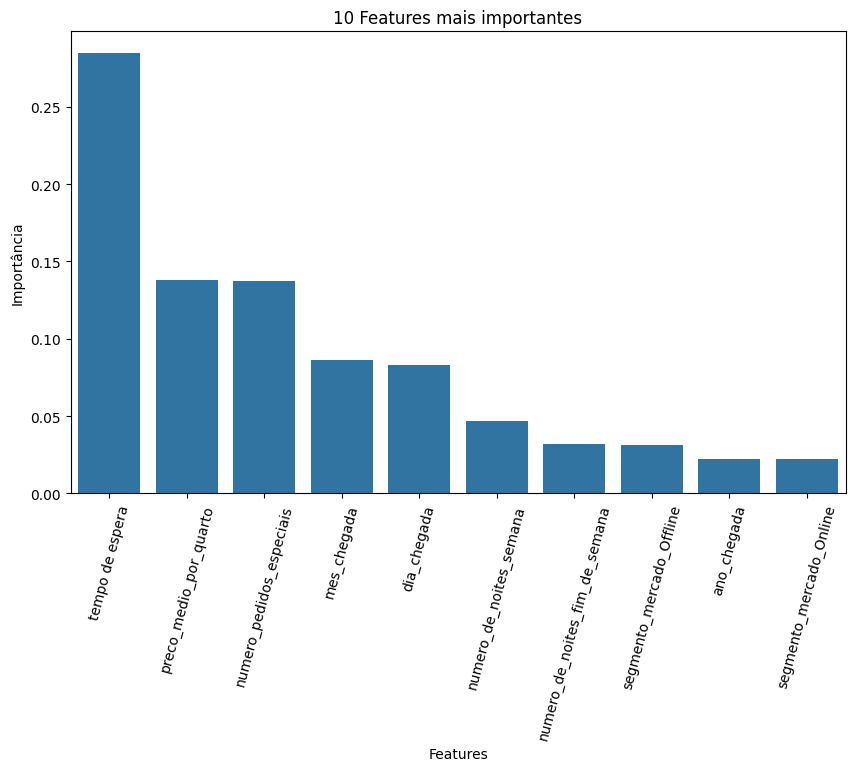

In [165]:
plt.figure(figsize=(10,6))

ax = sns.barplot(x='colunas', y='importancia', data=top10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=75)

plt.title('10 Features mais importantes')
plt.xlabel('Features')
plt.ylabel('Importância')

plt.show()

<Axes: >

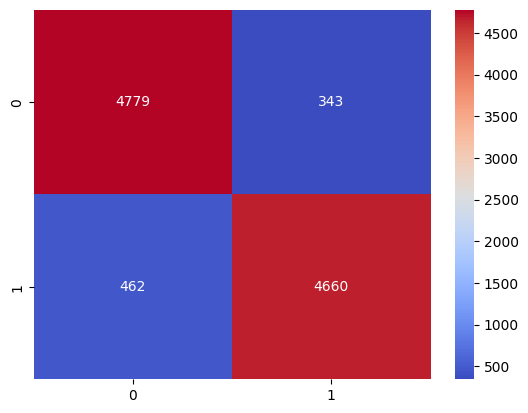

In [149]:
y_pred = rfecv.predict(X_teste)
matriz_confusao = confusion_matrix(y_teste,y_pred)
sns.heatmap(matriz_confusao, annot=True, cmap='coolwarm',fmt='d')

### Visualização dos resultados

In [151]:
resultado = rfecv.cv_results_
resultado['mean_test_score']

array([0.76154345, 0.87839775, 0.90458683, 0.94491056, 0.95526299,
       0.95713147, 0.96172095, 0.9619459 , 0.96508946, 0.96545119,
       0.96600555, 0.96636283, 0.96654828, 0.96653068, 0.96700983,
       0.96842023, 0.96922436, 0.96933057, 0.96897245, 0.96914412,
       0.96911669, 0.96916082, 0.96924454, 0.96912505, 0.96992768,
       0.96991859, 0.96983684, 0.96988479, 0.96954651, 0.96953734])

Text(0.5, 0, 'Número de features')

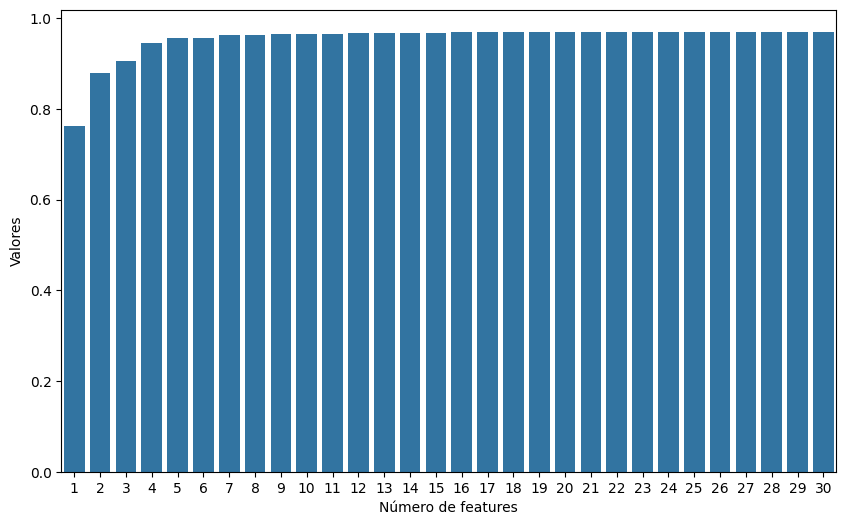

In [155]:
results_df = pd.DataFrame({'Valores': resultado['mean_test_score']})

plt.figure(figsize=(10,6))

sns.barplot(x=results_df.index+1, y='Valores', data=results_df)
plt.xlabel('Número de features')

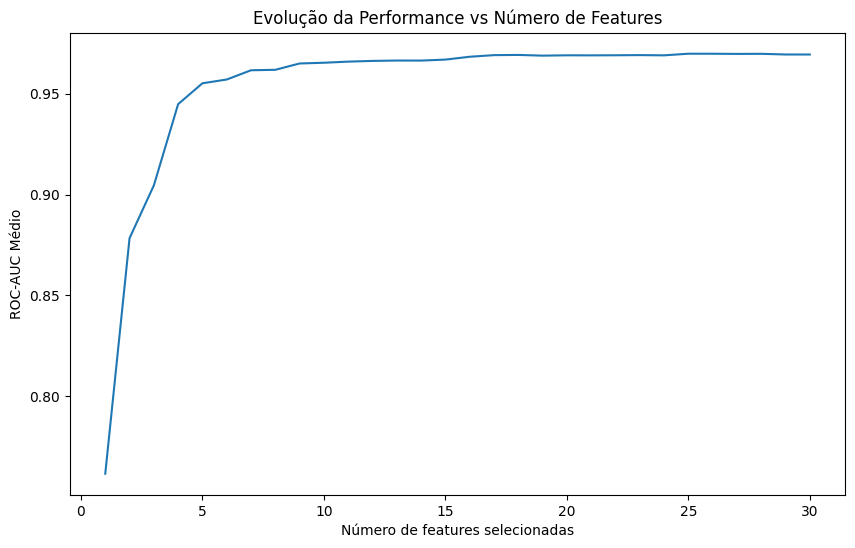

In [156]:
import matplotlib.pyplot as plt

# Criando um gráfico de performance
plt.figure(figsize=(10, 6))
plt.xlabel("Número de features selecionadas")
plt.ylabel("ROC-AUC Médio")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'])
plt.title("Evolução da Performance vs Número de Features")
plt.show()